# E-commerce Sales Analysis

## 1. Data Loading and Initial Audit

The dataset is loaded and examined to understand its structure, data types, completeness, and general characteristics.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9994
Columns: 21


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [11]:
df["Discount"].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [12]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

## 2. Data Preparation

Date columns are converted to datetime format to enable temporal analysis. Additional features are created to support the analysis.

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [14]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [15]:
df["Order Year"] = df["Order Date"].dt.year

In [47]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [16]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [17]:
df[["Order Date", "Ship Date"]].isna().sum()

Order Date    0
Ship Date     0
dtype: int64

In [18]:
df[["Sales", "Quantity", "Discount", "Profit"]].min()

Sales          0.444
Quantity       1.000
Discount       0.000
Profit     -6599.978
dtype: float64

In [19]:
df[["Sales", "Quantity", "Discount", "Profit"]].max()

Sales       22638.480
Quantity       14.000
Discount        0.800
Profit       8399.976
dtype: float64

In [20]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [21]:
import pandas as pd

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

## 3. Sales and Profit Analysis

This section evaluates the overall sales performance, total profit, and profit margin of the dataset.

In [22]:
df[["Sales", "Profit"]].sum()

Sales     2.297201e+06
Profit    2.863970e+05
dtype: float64

In [23]:
df["Profit"].sum() / df["Sales"].sum()

np.float64(0.12467217240315605)

In [24]:
df.groupby("Category")[["Sales", "Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## 4. Category Analysis

Sales and profit are compared across product categories to identify differences in financial performance.

In [25]:
df.groupby("Category")[["Sales", "Profit"]].sum().assign(
    Margin=lambda x: x["Profit"] / x["Sales"]
)

,Sales,Profit,Margin
Category,,,
Furniture,741999.7953,18451.2728,0.024867
Office Supplies,719047.0320,122490.8008,0.170352
Technology,836154.0330,145454.9481,0.173957


<Axes: xlabel='Category'>

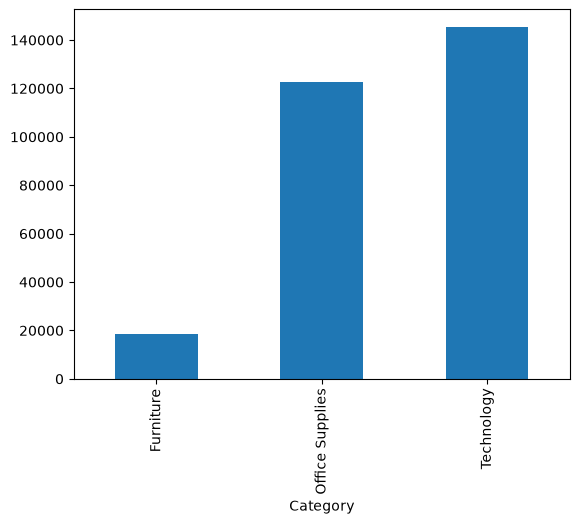

In [26]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar")

<Axes: xlabel='Category'>

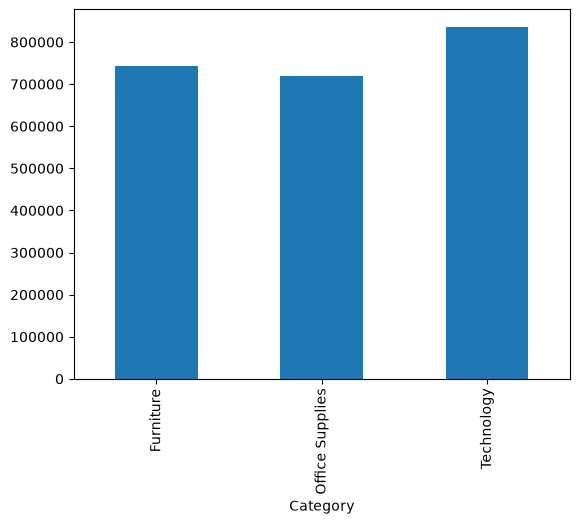

In [27]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

## 5. Discount Analysis

The relationship between discount levels and profitability is examined to identify patterns associated with lower financial performance.

In [28]:
df.groupby("Discount")["Profit"].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

<Axes: xlabel='Discount'>

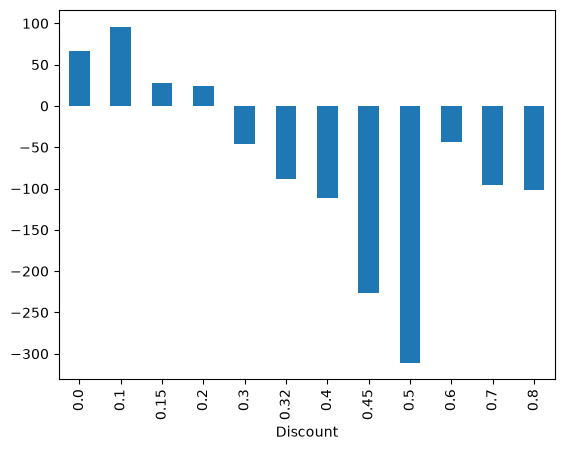

In [29]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit.plot(kind="bar")

In [30]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [31]:
df.groupby("Discount")["Sales"].sum().sort_index()

Discount
0.00    1.087908e+06
0.10    5.436935e+04
0.15    2.755852e+04
0.20    7.645944e+05
0.30    1.032267e+05
0.32    1.449346e+04
0.40    1.164178e+05
0.45    5.484974e+03
0.50    5.891854e+04
0.60    6.644700e+03
0.70    4.062028e+04
0.80    1.696376e+04
Name: Sales, dtype: float64

In [32]:
df.groupby("Discount")["Profit"].sum().sort_index()

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64

In [33]:
df["Order Date"].min(), df["Order Date"].max()

('1/1/2017', '9/9/2017')

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [35]:
df["Order Month"] = df["Order Date"].dt.to_period("M")

In [36]:
df["Order Month"] = df["Order Date"].dt.to_period("M")

In [37]:
df[["Order Date", "Order Month"]].head()

,Order Date,Order Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


## 6. Temporal Analysis

Sales performance is analyzed over time to identify trends and changes in annual and monthly revenue.

In [38]:
df.groupby("Order Month")["Sales"].sum()

Order Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160

<Axes: title={'center': 'Vendas mensais'}, xlabel='Order Month'>

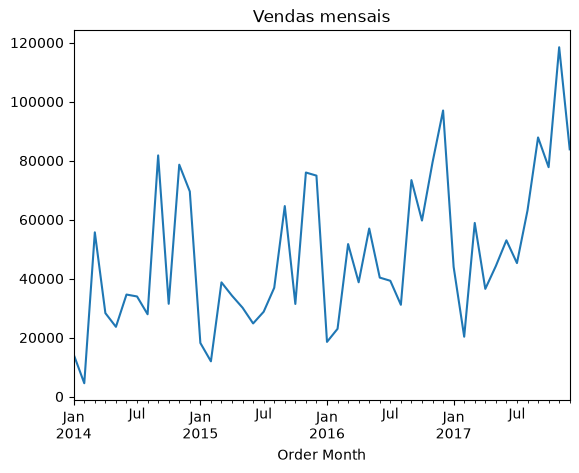

In [39]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

monthly_sales.plot(
    kind="line",
    title="Vendas mensais"
)

In [40]:
df.groupby(df["Order Date"].dt.year)["Sales"].sum()

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [41]:
df.groupby(df["Order Date"].dt.year)["Profit"].sum()

Order Date
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

## 7. Regional Analysis

Sales, profit, and profit margin are compared across regions to identify differences in regional performance.

In [42]:
df.groupby("Region")[["Sales", "Profit"]].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [43]:
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

region_analysis["Margin"] = region_analysis["Profit"] / region_analysis["Sales"]

region_analysis

,Sales,Profit,Margin
Region,,,
Central,501239.8908,39706.3625,0.079216
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
West,725457.8245,108418.4489,0.149448


In [44]:
subcategory_analysis = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_analysis.sort_values("Profit", ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


In [45]:
subcategory_analysis["Margin"] = (
    subcategory_analysis["Profit"] / subcategory_analysis["Sales"]
)

subcategory_analysis.sort_values("Margin", ascending=False)

,Sales,Profit,Margin
Sub-Category,,,
Labels,12486.3120,5546.2540,0.444187
Paper,78479.2060,34053.5693,0.433918
Envelopes,16476.4020,6964.1767,0.422676
Copiers,149528.0300,55617.8249,0.371956
Fasteners,3024.2800,949.5182,0.313965
Accessories,167380.3180,41936.6357,0.250547
Art,27118.7920,6527.7870,0.240711
Appliances,107532.1610,18138.0054,0.168675
Binders,203412.7330,30221.7633,0.148574


## 8. Sub-Category Analysis

Product sub-categories are compared by sales, profit, profit margin, and average discount to identify the most and least profitable areas.

In [46]:
df.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False)

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64

## 9. Key Findings

- Total sales were approximately $2.30M, with total profit of approximately $286K.
- The overall profit margin was approximately 12.47%.
- Technology generated the highest total sales and profit among the three categories.
- Furniture had substantially lower profitability than Office Supplies and Technology.
- Higher discount levels were associated with lower profitability, with observed levels from 30% onward generating negative total profit.
- Sales increased by approximately 51.4% between 2014 and 2017.
- The West region had the highest sales, profit, and profit margin.
- Tables generated more than $206K in sales but resulted in a negative profit of approximately $17.7K.
- Labels had the highest profit margin at approximately 44.4%.